Dataset extracted!
['no', 'yes', 'brain_tumor_dataset']
Found 253 files belonging to 2 classes.
Using 203 files for training.
Found 253 files belonging to 2 classes.
Using 50 files for validation.
Classes: ['no', 'yes']
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6552 - loss: 0.7510 - val_accuracy: 0.7800 - val_loss: 0.5946
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 857ms/step - accuracy: 0.7586 - loss: 0.5615 - val_accuracy: 0.6200 - val_loss: 0.6043
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.8030 - loss: 0.4672 - val_accuracy: 0.8000 - val_loss: 0.5707
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 825ms/step - accuracy: 0.7882 - loss: 0.4587 - val_accuracy: 0.8200 - val_loss: 0.5522
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7882 - loss: 0.4183 - val_accuracy: 0.8000 - val_loss: 0.5893
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 819ms/step - accuracy: 0.8473 - loss: 0.3671 - val_accuracy: 0.8000 - val_loss: 0.5869
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━

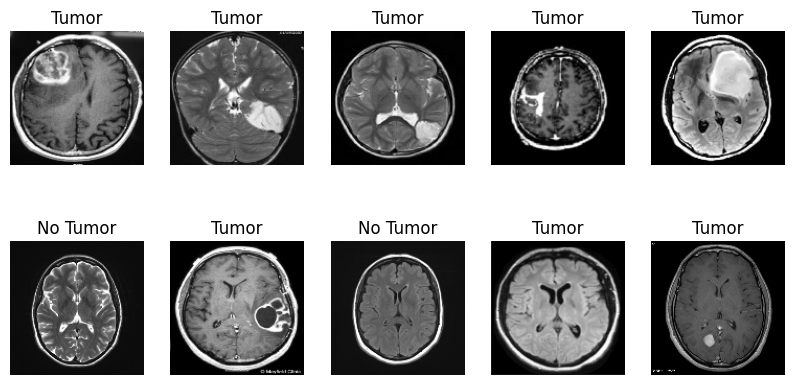

In [37]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# Dataset path
import zipfile
import os

zip_path = "/content/archive (21).zip"
extract_path = "/content/brain_tumor_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

# Corrected path to list the extracted directory
print(os.listdir(extract_path))

# Adjust the dataset path to point to the directory containing the class folders ('no', 'yes')
# Based on the os.listdir output, the actual data is in brain_tumor_dataset/brain_tumor_dataset
dataset_root_path = os.path.join(extract_path, 'brain_tumor_dataset')

# Load images from folders
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_root_path, # Changed from extract_path to dataset_root_path
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_root_path, # Changed from extract_path to dataset_root_path
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Normalize images
normalization_layer = keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# CNN Model
model = keras.Sequential([
    keras.Input(shape=(128, 128, 3)), # Explicitly define Input layer to address UserWarning
    keras.layers.Conv2D(
        32, (3,3),
        activation='relu'
    ),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),

    keras.layers.Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Evaluate
loss, acc = model.evaluate(val_ds)

print(f"\nValidation Accuracy: {acc:.4f}")

# Prediction on a few images
for images, labels in val_ds.take(1):

    predictions = model.predict(images)

    plt.figure(figsize=(10,5))

    for i in range(10):

        plt.subplot(2,5,i+1)
        plt.imshow(images[i])

        pred = "Tumor" if predictions[i] > 0.5 else "No Tumor"

        plt.title(pred)
        plt.axis("off")

    plt.show()

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
zip_path = "archive (21).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully")

In [ ]:
dataset_path = "dataset/brain_tumor_dataset"

In [ ]:
yes_count = len(os.listdir(os.path.join(dataset_path, "yes")))
no_count = len(os.listdir(os.path.join(dataset_path, "no")))

print("Tumor Images :", yes_count)
print("No Tumor Images :", no_count)

In [ ]:
import cv2

plt.figure(figsize=(10,5))

tumor_img = os.listdir(os.path.join(dataset_path,"yes"))[0]
normal_img = os.listdir(os.path.join(dataset_path,"no"))[0]

img1 = cv2.imread(os.path.join(dataset_path,"yes",tumor_img))
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

img2 = cv2.imread(os.path.join(dataset_path,"no",normal_img))
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("Tumor")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("No Tumor")

plt.show()

In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

In [ ]:
print(train_data.class_indices)

In [ ]:
model = Sequential()

# Layer 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 3
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layers
model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

In [ ]:
model.summary()

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

In [ ]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy :", accuracy)

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

In [ ]:
model.save("brain_tumor_cnn.h5")

print("Model Saved")

In [ ]:
from tensorflow.keras.preprocessing import image

# Corrected img_path to use an existing image file
img_path = "/content/3c7b18a8-c266-455c-b552-dd660d9fac50.jpg.jpeg"

img = image.load_img(
    img_path,
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array/255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

print(prediction)

In [ ]:
if prediction[0][0] > 0.5:
    print("Brain Tumor Detected")
else:
    print("No Brain Tumor")

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

In [ ]:
dataset_path = "dataset/brain_tumor_dataset"

images = []
labels = []

In [ ]:
tumor_folder = os.path.join(dataset_path,"yes")

for img_name in os.listdir(tumor_folder):

    img_path = os.path.join(
        tumor_folder,
        img_name
    )

    img = cv2.imread(img_path)

    img = cv2.resize(
        img,
        (128,128)
    )

    images.append(img)
    labels.append(1)

In [ ]:
normal_folder = os.path.join(dataset_path,"no")

for img_name in os.listdir(normal_folder):

    img_path = os.path.join(
        normal_folder,
        img_name
    )

    img = cv2.imread(img_path)

    img = cv2.resize(
        img,
        (128,128)
    )

    images.append(img)
    labels.append(0)

In [ ]:
X = np.array(images)

y = np.array(labels)

print(X.shape)
print(y.shape)

In [ ]:
X = X / 255.0

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train_ml = X_train.reshape(
    X_train.shape[0],
    -1
)

X_test_ml = X_test.reshape(
    X_test.shape[0],
    -1
)

print(X_train_ml.shape)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train_ml,
    y_train
)

In [ ]:
y_pred_ml = rf.predict(
    X_test_ml
)

In [ ]:
ml_accuracy = accuracy_score(
    y_test,
    y_pred_ml
)

print(
    "Machine Learning Accuracy:",
    ml_accuracy
)

In [ ]:
cnn = Sequential()

cnn.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

cnn.add(
    MaxPooling2D((2,2))
)

cnn.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

cnn.add(
    MaxPooling2D((2,2))
)

cnn.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

cnn.add(
    MaxPooling2D((2,2))
)

cnn.add(Flatten())

cnn.add(Dense(
    128,
    activation='relu'
))

cnn.add(
    Dropout(0.5)
)

cnn.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

In [ ]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [33]:
history = cnn.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 859ms/step - accuracy: 0.6708 - loss: 0.6097 - val_accuracy: 0.7561 - val_loss: 0.5457
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 975ms/step - accuracy: 0.7578 - loss: 0.5319 - val_accuracy: 0.8049 - val_loss: 0.5379
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 815ms/step - accuracy: 0.7019 - loss: 0.5188 - val_accuracy: 0.7561 - val_loss: 0.6438
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 769ms/step - accuracy: 0.8137 - loss: 0.4574 - val_accuracy: 0.7805 - val_loss: 0.6971
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7950 - loss: 0.4644 - val_accuracy: 0.7561 - val_loss: 0.7928
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 823ms/step - accuracy: 0.7950 - loss: 0.4387 - val_accuracy: 0.8049 - val_loss: 0.5492
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 779ms/step - accuracy: 0.7516 - loss: 0.4504 - val_accuracy: 0.7073 - val_loss: 0.7502
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8137 - loss: 0.4107 - val_accuracy: 0.8537 - val_loss: 0.

In [34]:
loss, dl_accuracy = cnn.evaluate(
    X_test,
    y_test
)

print(
    "Deep Learning Accuracy:",
    dl_accuracy
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.8235 - loss: 0.5214
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.8235 - loss: 0.5214
Deep Learning Accuracy: 0.8235294222831726
Deep Learning Accuracy: 0.8235294222831726


In [35]:
print("\nMODEL COMPARISON")
print("--------------------------")
print("Random Forest :", ml_accuracy)
print("CNN           :", dl_accuracy)


MODEL COMPARISON
--------------------------
Random Forest : 0.7843137254901961
CNN           : 0.8235294222831726

MODEL COMPARISON
--------------------------
Random Forest : 0.7843137254901961
CNN           : 0.8235294222831726


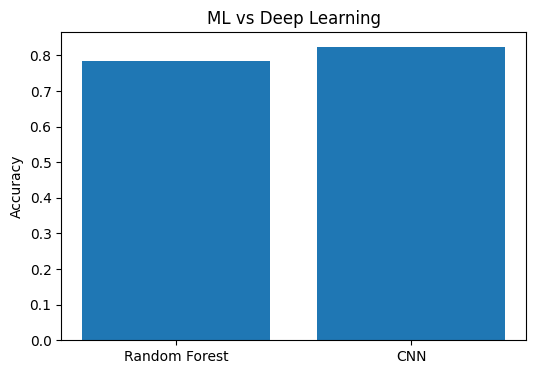

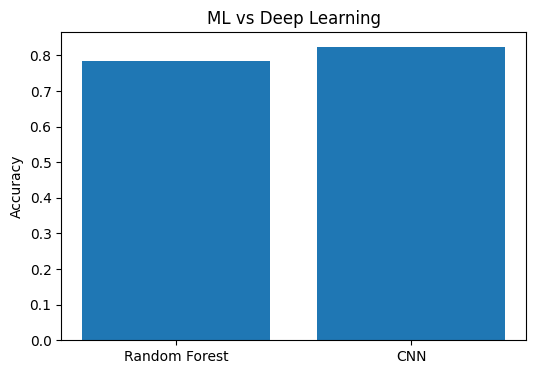

In [36]:
models = [
    "Random Forest",
    "CNN"
]

scores = [
    ml_accuracy,
    dl_accuracy
]

plt.figure(figsize=(6,4))

plt.bar(
    models,
    scores
)

plt.ylabel("Accuracy")
plt.title("ML vs Deep Learning")

plt.show()